In [1]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("git clone https://github.com/thezettascale/fp-emulation.git 2>/dev/null")
    sys.path.insert(0, "/content/fp-emulation/src")
else:
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

# Stochastic Rounding vs Ozaki for PINNs

- **Stochastic rounding (SR)**: stay low precision, round randomly so errors cancel out. Cheap, single pass. [Hardware exists](https://arxiv.org/html/2404.14010v1).
- **Ozaki**: reconstruct exact FP64 from INT8 ops. Multiple passes, deterministic.

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from fp_emulation import convert

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

fig_dir = Path("figures")
if not Path("src").exists():
    fig_dir = Path("..") / "figures"

fig_dir.mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce GTX 1650


## Stochastic rounding

Round up or down randomly, propto to distance. E[SR(x)] = x, no bias. Prevents stagnation where small updates get rounded away to zero.

Graphcore IPU does this in hardware. We can simulate it in torch with a straight-through estimator, (forward rounds, backward passes through).

In [ ]:
def stochastic_round_bf16(x):
    """
    Simulate SR

    Round to BF16 precision stochastically.
    Straight-through estimator for gradients.
    """
    x_bf16 = x.bfloat16().double()
    residual = x - x_bf16
    ulp = torch.abs(x_bf16) * (2.0**-7)  # BF16 has 8-bit mantissa (7 explicit)
    ulp = ulp.clamp(min=torch.finfo(torch.bfloat16).tiny)
    prob = (residual.abs() / ulp).clamp(0, 1)
    flip = torch.bernoulli(
        prob.float()
    ).double()  # Not differentiable (hw implementation would be)
    correction = flip * ulp * residual.sign()
    rounded = x_bf16 + correction
    return x + (rounded - x).detach()


class SRLinear(nn.Module):
    """Linear layer w/ simulated stochastic rounding to BF16 after matmul."""

    def __init__(self, linear):
        super().__init__()
        self.linear = linear

    def forward(self, x):
        out = self.linear(x)
        if self.training:
            out = stochastic_round_bf16(out)
        return out


def convert_sr(model):
    """Swap nn.Linear -> SRLinear."""
    for name, child in model.named_children():
        if isinstance(child, nn.Linear):
            setattr(model, name, SRLinear(child))
        else:
            convert_sr(child)
    return model

## Burgers' equation

$u_t + u \, u_x = \nu \, u_{xx}$. Second-order derivatives through autograd. Where low precision breaks.

In [4]:
nu = 0.01 / torch.pi


def make_pinn():
    return nn.Sequential(
        nn.Linear(2, 256),
        nn.Tanh(),
        nn.Linear(256, 256),
        nn.Tanh(),
        nn.Linear(256, 256),
        nn.Tanh(),
        nn.Linear(256, 1),
    ).to(dtype=torch.float64, device=device)


# fixed collocation grid
x_col = torch.linspace(-1, 1, 20, dtype=torch.float64, device=device)
t_col = torch.linspace(0, 1, 20, dtype=torch.float64, device=device)
xx, tt = torch.meshgrid(x_col, t_col, indexing="ij")
x_pde = xx.reshape(-1, 1)
t_pde = tt.reshape(-1, 1)

x_ic = torch.linspace(-1, 1, 50, dtype=torch.float64, device=device).unsqueeze(1)
t_ic = torch.zeros_like(x_ic)
t_bc = torch.linspace(0, 1, 30, dtype=torch.float64, device=device).unsqueeze(1)


def burgers_loss(model):
    dtype = next(model.parameters()).dtype
    x = x_pde.to(dtype).requires_grad_(True)
    t = t_pde.to(dtype).requires_grad_(True)
    u = model(torch.cat([x, t], dim=1))

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    pde = (u_t + u * u_x - nu * u_xx).pow(2).mean()

    u_ic = model(torch.cat([x_ic.to(dtype), t_ic.to(dtype)], dim=1))
    ic = (u_ic + torch.sin(torch.pi * x_ic.to(dtype))).pow(2).mean()

    u_left = model(
        torch.cat([torch.full_like(t_bc, -1, dtype=dtype), t_bc.to(dtype)], dim=1)
    )
    u_right = model(
        torch.cat([torch.full_like(t_bc, 1, dtype=dtype), t_bc.to(dtype)], dim=1)
    )
    bc = (u_left.pow(2) + u_right.pow(2)).mean()

    return pde + 10 * ic + 10 * bc


def train(model, n_epochs=500, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = burgers_loss(model)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

## Train: FP64 vs FP32 vs SR vs Ozaki INT8

In [5]:
# FP64 baseline
torch.manual_seed(0)
model_fp64 = make_pinn()
losses_fp64 = train(model_fp64)
print(f"FP64 final loss: {losses_fp64[-1]:.4e}")

# FP32
torch.manual_seed(0)
model_fp32 = nn.Sequential(
    nn.Linear(2, 256),
    nn.Tanh(),
    nn.Linear(256, 256),
    nn.Tanh(),
    nn.Linear(256, 256),
    nn.Tanh(),
    nn.Linear(256, 1),
).to(dtype=torch.float32, device=device)
losses_fp32 = train(model_fp32)
print(f"FP32 final loss: {losses_fp32[-1]:.4e}")

# BF16 + stochastic rounding
torch.manual_seed(0)
model_sr = convert_sr(make_pinn())
losses_sr = train(model_sr)
print(f"BF16+SR final loss: {losses_sr[-1]:.4e}")

# INT8 Ozaki (exact FP64)
torch.manual_seed(0)
model_ozaki = convert(make_pinn())
losses_ozaki = train(model_ozaki)
print(f"Ozaki final loss:   {losses_ozaki[-1]:.4e}")

/home/pritmanguy/Work/fp-emulation/.venv/lib/python3.14/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


FP64 final loss: 5.8046e-01
FP32 final loss: 3.3014e-01
BF16+SR final loss: 2.6828e-01
Ozaki final loss:   5.8046e-01


## Results

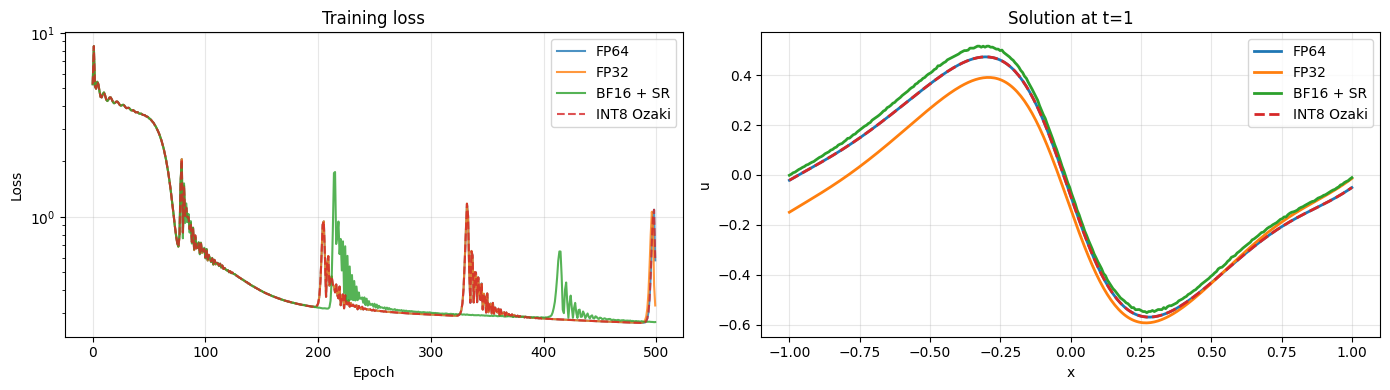

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# loss curves
ax = axes[0]
ax.semilogy(losses_fp64, label="FP64", alpha=0.8)
ax.semilogy(losses_fp32, label="FP32", alpha=0.8)
ax.semilogy(losses_sr, label="BF16 + SR", alpha=0.8)
ax.semilogy(losses_ozaki, label="INT8 Ozaki", alpha=0.8, ls="--")
ax.set(xlabel="Epoch", ylabel="Loss", title="Training loss")
ax.legend()
ax.grid(True, alpha=0.3)

# solution at t=1
ax = axes[1]
x_plot = torch.linspace(-1, 1, 300, dtype=torch.float64, device=device).unsqueeze(1)
t_plot = torch.ones_like(x_plot)
xt = torch.cat([x_plot, t_plot], dim=1)

with torch.no_grad():
    u_fp64 = model_fp64(xt).cpu()
    u_fp32 = model_fp32(xt.float()).cpu()
    u_sr = model_sr(xt).cpu()
    u_ozaki = model_ozaki(xt).cpu()

ax.plot(x_plot.cpu(), u_fp64, label="FP64", lw=2)
ax.plot(x_plot.cpu(), u_fp32, label="FP32", lw=2)
ax.plot(x_plot.cpu(), u_sr, label="BF16 + SR", lw=2)
ax.plot(x_plot.cpu(), u_ozaki, "--", label="INT8 Ozaki", lw=2)
ax.set(xlabel="x", ylabel="u", title="Solution at t=1")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(fig_dir / "sr_vs_ozaki.png", dpi=150, bbox_inches="tight")
plt.show()